# Part 1a: L1 & L2 Regularization — TensorFlow & PyTorch

**Objective:** Demonstrate L1, L2, and Elastic Net regularization with A/B comparison (regularized vs unregularized) on a classification task.

**Dataset:** CIFAR-10 (simplified to 2 classes for speed)

---

In [1]:
# Cell 1: Install and import libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
print(f"TensorFlow version: {tf.__version__}")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
print(f"PyTorch version: {torch.__version__}")

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128


## Section 1: Data Preparation
We load CIFAR-10 via Keras, normalize pixel values to [0,1], and use all 10 classes.

In [2]:
# Cell 2: Load and preprocess CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

# Flatten for dense network demo
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Training set: {X_train_flat.shape}, Labels: {y_train.shape}")
print(f"Test set: {X_test_flat.shape}, Labels: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training set: (50000, 3072), Labels: (50000,)
Test set: (10000, 3072), Labels: (10000,)


## Section 2: TensorFlow — No Regularization (Baseline)

In [3]:
# Cell 3: TF Baseline model — no regularization
def build_tf_model(regularizer=None, name="model"):
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizer),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizer),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizer),
        layers.Dense(10, activation='softmax')
    ], name=name)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tf_baseline = build_tf_model(regularizer=None, name="tf_baseline")
tf_baseline.summary()

Model: "tf_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 828,490 (3.16 MB)

 Trainable params: 828,490 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Cell 4: Train TF Baseline
history_baseline = tf_baseline.fit(
    X_train_flat, y_train,
    epochs=30, batch_size=256,
    validation_split=0.2, verbose=1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.2916 - loss: 1.9584 - val_accuracy: 0.3539 - val_loss: 1.8307
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3742 - loss: 1.7583 - val_accuracy: 0.3739 - val_loss: 1.7643
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4023 - loss: 1.6726 - val_accuracy: 0.3925 - val_loss: 1.7463
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4157 - loss: 1.6332 - val_accuracy: 0.4160 - val_loss: 1.6442
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4410 - loss: 1.5706 - val_accuracy: 0.4349 - val_loss: 1.6008
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4521 - loss: 1.5376 - val_accuracy: 0.4362 - val_loss: 1.5790
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4626 - loss: 1.5066 - val_accuracy: 0.4462 - val_loss: 1.5577
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4750 - loss: 1.4773 - val_accuracy: 0

## Section 3: TensorFlow — L1 Regularization
L1 regularization adds the sum of absolute values of weights to the loss. It encourages sparsity — many weights become exactly zero.

In [5]:
# Cell 5: TF L1 Model
tf_l1 = build_tf_model(regularizer=regularizers.l1(1e-4), name="tf_l1")
history_l1 = tf_l1.fit(
    X_train_flat, y_train,
    epochs=30, batch_size=256,
    validation_split=0.2, verbose=1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.2886 - loss: 3.1013 - val_accuracy: 0.3391 - val_loss: 2.5185
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3722 - loss: 2.2811 - val_accuracy: 0.3698 - val_loss: 2.1864
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3859 - loss: 2.1008 - val_accuracy: 0.3839 - val_loss: 2.0658
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4091 - loss: 1.9861 - val_accuracy: 0.3875 - val_loss: 1.9874
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4143 - loss: 1.9225 - val_accuracy: 0.3745 - val_loss: 2.0091
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4264 - loss: 1.8649 - val_accuracy: 0.3803 - val_loss: 1.9807
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4275 - loss: 1.8422 - val_accuracy: 0.4352 - val_loss: 1.8351
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4423 - loss: 1.7891 - val_accuracy: 0

## Section 4: TensorFlow — L2 Regularization
L2 regularization adds the sum of squared weights to the loss. It penalizes large weights but doesn't force them to zero — it encourages small, distributed weights.

In [6]:
# Cell 6: TF L2 Model
tf_l2 = build_tf_model(regularizer=regularizers.l2(1e-4), name="tf_l2")
history_l2 = tf_l2.fit(
    X_train_flat, y_train,
    epochs=30, batch_size=256,
    validation_split=0.2, verbose=1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.2918 - loss: 2.0295 - val_accuracy: 0.3509 - val_loss: 1.8821
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3663 - loss: 1.8207 - val_accuracy: 0.3502 - val_loss: 1.8755
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3930 - loss: 1.7388 - val_accuracy: 0.3835 - val_loss: 1.7762
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4147 - loss: 1.6768 - val_accuracy: 0.4007 - val_loss: 1.7230
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4364 - loss: 1.6193 - val_accuracy: 0.4315 - val_loss: 1.6369
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4523 - loss: 1.5765 - val_accuracy: 0.4231 - val_loss: 1.6472
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4613 - loss: 1.5478 - val_accuracy: 0.4419 - val_loss: 1.6169
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4684 - loss: 1.5229 - val_accuracy: 0

## Section 5: TensorFlow — Elastic Net (L1+L2)
Elastic Net combines L1 and L2 penalties, getting benefits of both: sparsity from L1, stability from L2.

In [7]:
# Cell 7: TF Elastic Net Model
tf_elastic = build_tf_model(regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-4), name="tf_elastic")
history_elastic = tf_elastic.fit(
    X_train_flat, y_train,
    epochs=30, batch_size=256,
    validation_split=0.2, verbose=1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.2927 - loss: 3.0343 - val_accuracy: 0.3416 - val_loss: 2.4355
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3668 - loss: 2.2761 - val_accuracy: 0.3784 - val_loss: 2.1596
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3916 - loss: 2.0747 - val_accuracy: 0.3752 - val_loss: 2.0794
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4000 - loss: 1.9862 - val_accuracy: 0.3974 - val_loss: 2.0089
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4140 - loss: 1.9244 - val_accuracy: 0.3849 - val_loss: 1.9875
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4193 - loss: 1.8828 - val_accuracy: 0.4279 - val_loss: 1.8669
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4232 - loss: 1.8449 - val_accuracy: 0.3675 - val_loss: 2.0003
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4312 - loss: 1.8146 - val_accuracy: 0

## Section 6: TensorFlow A/B Comparison Plot

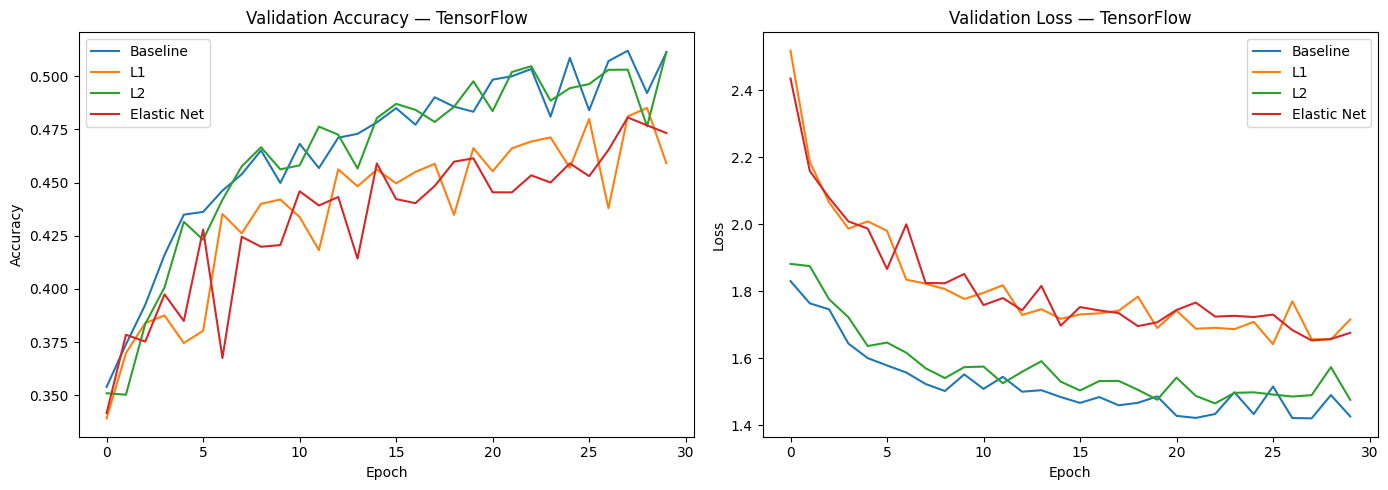

TF Baseline: Test Accuracy = 0.5103, Test Loss = 1.4075
TF L1: Test Accuracy = 0.4615, Test Loss = 1.7042
TF L2: Test Accuracy = 0.5121, Test Loss = 1.4633
TF Elastic: Test Accuracy = 0.4766, Test Loss = 1.6627


In [8]:
# Cell 8: Compare all TF models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

histories = {
    'Baseline': history_baseline,
    'L1': history_l1,
    'L2': history_l2,
    'Elastic Net': history_elastic
}

for name, h in histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].plot(h.history['val_loss'], label=name)

axes[0].set_title('Validation Accuracy — TensorFlow')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].set_title('Validation Loss — TensorFlow')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# Print final test accuracies
for name, model in [('Baseline', tf_baseline), ('L1', tf_l1), ('L2', tf_l2), ('Elastic', tf_elastic)]:
    loss, acc = model.evaluate(X_test_flat, y_test, verbose=0)
    print(f"TF {name}: Test Accuracy = {acc:.4f}, Test Loss = {loss:.4f}")

---
## Section 7: PyTorch Implementation
Now we replicate the same experiments in PyTorch. PyTorch applies L2 via the `weight_decay` parameter in the optimizer. For L1, we add it manually to the loss.

In [9]:
# Cell 9: Prepare PyTorch data
X_train_t = torch.FloatTensor(X_train_flat)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test_flat)
y_test_t = torch.LongTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
# Cell 10: PyTorch model definition
class DenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

def train_pytorch(model, train_loader, test_loader, epochs=30,
                  weight_decay=0.0, l1_lambda=0.0):
    """Generic PyTorch training loop with optional L1/L2 regularization."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # weight_decay in Adam implements L2 regularization
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Manual L1 regularization
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm

            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(y_batch).sum().item()
            total += y_batch.size(0)

        history['train_acc'].append(correct / total)
        history['train_loss'].append(running_loss / total)

        # Validation
        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(y_batch).sum().item()
                total += y_batch.size(0)
        history['val_acc'].append(correct / total)
        history['val_loss'].append(val_loss / total)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Train Acc: {history['train_acc'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.4f}")
    return history

In [11]:
# Cell 11: Train all PyTorch variants
print("=== PyTorch Baseline (No Regularization) ===")
pt_baseline = DenseNet()
pt_hist_baseline = train_pytorch(pt_baseline, train_loader, test_loader)

print("\n=== PyTorch L2 (weight_decay=1e-4) ===")
pt_l2 = DenseNet()
pt_hist_l2 = train_pytorch(pt_l2, train_loader, test_loader, weight_decay=1e-4)

print("\n=== PyTorch L1 (manual, lambda=1e-5) ===")
pt_l1 = DenseNet()
pt_hist_l1 = train_pytorch(pt_l1, train_loader, test_loader, l1_lambda=1e-5)

print("\n=== PyTorch Elastic Net (L1+L2) ===")
pt_elastic = DenseNet()
pt_hist_elastic = train_pytorch(pt_elastic, train_loader, test_loader, weight_decay=1e-4, l1_lambda=1e-5)

=== PyTorch Baseline (No Regularization) ===
Epoch 10/30 — Train Acc: 0.5003, Val Acc: 0.4819
Epoch 20/30 — Train Acc: 0.5634, Val Acc: 0.4940
Epoch 30/30 — Train Acc: 0.6052, Val Acc: 0.5273

=== PyTorch L2 (weight_decay=1e-4) ===
Epoch 10/30 — Train Acc: 0.5017, Val Acc: 0.4575
Epoch 20/30 — Train Acc: 0.5611, Val Acc: 0.5123
Epoch 30/30 — Train Acc: 0.5995, Val Acc: 0.5134

=== PyTorch L1 (manual, lambda=1e-5) ===
Epoch 10/30 — Train Acc: 0.4918, Val Acc: 0.4858
Epoch 20/30 — Train Acc: 0.5446, Val Acc: 0.5089
Epoch 30/30 — Train Acc: 0.5799, Val Acc: 0.5100

=== PyTorch Elastic Net (L1+L2) ===
Epoch 10/30 — Train Acc: 0.4961, Val Acc: 0.4772
Epoch 20/30 — Train Acc: 0.5445, Val Acc: 0.5088
Epoch 30/30 — Train Acc: 0.5813, Val Acc: 0.5231


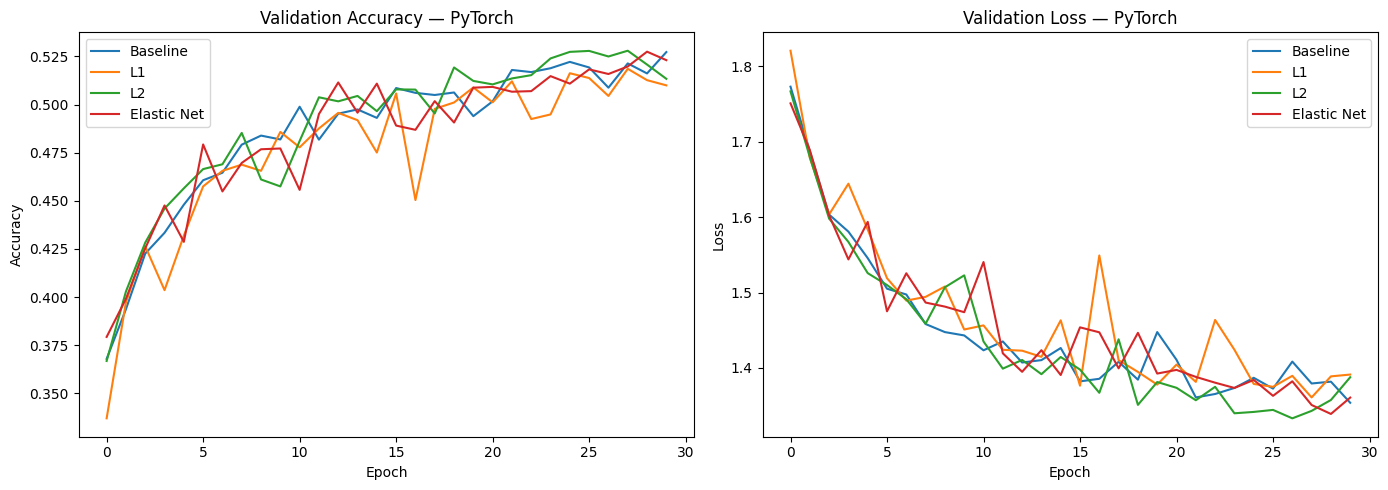

In [12]:
# Cell 12: Compare all PyTorch models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pt_histories = {
    'Baseline': pt_hist_baseline,
    'L1': pt_hist_l1,
    'L2': pt_hist_l2,
    'Elastic Net': pt_hist_elastic
}

for name, h in pt_histories.items():
    axes[0].plot(h['val_acc'], label=name)
    axes[1].plot(h['val_loss'], label=name)

axes[0].set_title('Validation Accuracy — PyTorch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].set_title('Validation Loss — PyTorch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

## Key Takeaways

| Technique | What it does | When to use |
|-----------|-------------|-------------|
| **L1** | Adds |w| penalty → sparse weights | Feature selection, when many features are irrelevant |
| **L2** | Adds w² penalty → small weights | General overfitting prevention, most common choice |
| **Elastic Net** | Combines L1 + L2 | When you want both sparsity and stability |

**Observation:** Regularized models typically show a smaller gap between training and validation accuracy, indicating reduced overfitting.